# Phase 2: Data Preprocessing & Post-Cleaning EDA
This notebook cleans the data, scales it, and visualizes the effectiveness of the preprocessing. We DO NOT apply SMOTE here to prevent Data Leakage into the test set later.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import os

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.autolayout': True})

CSV_PATH = "../data/US_Accidents.csv"
print("Loading 500k random sample for Preprocessing...")

chunks = []
for chunk in pd.read_csv(CSV_PATH, chunksize=500_000, low_memory=False):
    chunks.append(chunk.sample(frac=0.065, random_state=42)) 
    
df = pd.concat(chunks, ignore_index=True)
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed')

print(f"Loaded raw data: {df.shape}")

Loading 500k random sample for Preprocessing...
Loaded raw data: (502346, 46)


### Graph 1: Pre vs Post Imputation Proof
We will impute missing values with the median. We also print a specific row before and after to prove the NaN was filled.

================ IMPUTATION EXAMPLE ================
BEFORE Imputation (Row 73):
ID                A-128707
Visibility(mi)         NaN
Name: 73, dtype: object
-----------------------------------------------------
AFTER Imputation (Row 73):
ID                A-128707
Visibility(mi)        10.0
Name: 73, dtype: object



/opt/anaconda3/envs/py311/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py311/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


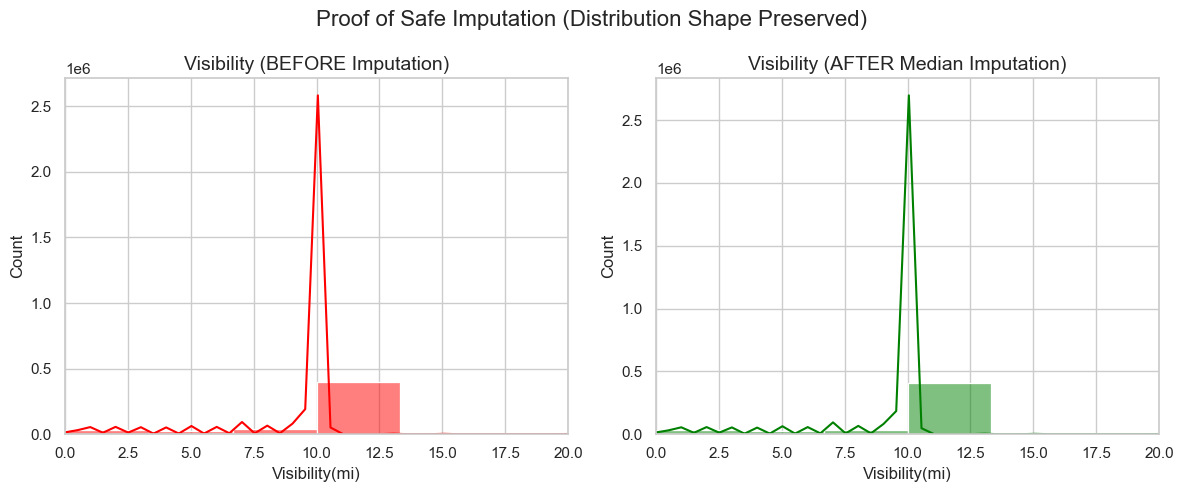

In [12]:
# Find a row where Visibility is NaN to show as an example
example_nan_idx = df[df['Visibility(mi)'].isna()].index[0]

print("================ IMPUTATION EXAMPLE ================")
print(f"BEFORE Imputation (Row {example_nan_idx}):")
print(df.loc[example_nan_idx, ['ID', 'Visibility(mi)']])
print("-----------------------------------------------------")

plt.figure(figsize=(12, 5))
original_visibility = df['Visibility(mi)'].copy()

# Fill missing values with the median
median_vis = df['Visibility(mi)'].median()
df['Visibility(mi)'] = df['Visibility(mi)'].fillna(median_vis)

# Impute the other numeric columns as well
for col in ['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Wind_Speed(mph)']:
    df[col] = df[col].fillna(df[col].median())

print(f"AFTER Imputation (Row {example_nan_idx}):")
print(df.loc[example_nan_idx, ['ID', 'Visibility(mi)']])
print("====================================================\n")

# Plot Before vs After
plt.subplot(1, 2, 1)
sns.histplot(original_visibility.dropna(), bins=30, color='red', kde=True)
plt.title('Visibility (BEFORE Imputation)', fontsize=14)
plt.xlim(0, 20)

plt.subplot(1, 2, 2)
sns.histplot(df['Visibility(mi)'], bins=30, color='green', kde=True)
plt.title('Visibility (AFTER Median Imputation)', fontsize=14)
plt.xlim(0, 20)

plt.suptitle("Proof of Safe Imputation (Distribution Shape Preserved)", fontsize=16)
plt.show()

### Feature Engineering & Dropping Useless Columns

In [13]:
example_idx = 0

print("================ FEATURE ENGINEERING EXAMPLE ================")
print(f"BEFORE (Row {example_idx}): Raw strings and complex timestamps")
print(df.loc[example_idx, ['Start_Time', 'Sunrise_Sunset']])
print("--------------------------------------------------------------")

df['Hour'] = df['Start_Time'].dt.hour
df['Is_Weekend'] = df['Start_Time'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)
df['Is_Night'] = df['Sunrise_Sunset'].map({'Night': 1, 'Day': 0}).fillna(0)

# Group weather into top 10 categories + 'Other' to prevent 100+ columns
top_weather = df['Weather_Condition'].value_counts().head(10).index
df['Weather_Grouped'] = df['Weather_Condition'].apply(lambda x: x if x in top_weather else 'Other')

cols_to_drop = [
    'ID', 'Source', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng',
    'Distance(mi)', 'Description', 'Street', 'City', 'County', 'Zipcode', 'Country', 'Timezone',
    'Airport_Code', 'Weather_Timestamp', 'Wind_Direction', 'Weather_Condition',
    'Wind_Chill(F)', 'Precipitation(in)', # Dropped due to >25% missing data
    'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight'
]
df_clean = df.drop(columns=cols_to_drop)
df_clean = df_clean.dropna()

print(f"AFTER (Row {example_idx}): Clean, ML-ready integers")
print(df_clean.loc[example_idx, ['Hour', 'Is_Night', 'Is_Weekend']])
print("=============================================================\n")

print(f"Clean dataset shape: {df_clean.shape}")

================ FEATURE ENGINEERING EXAMPLE ================
BEFORE (Row 0): Raw strings and complex timestamps
Start_Time        2016-04-25 17:18:11
Sunrise_Sunset                    Day
Name: 0, dtype: object
--------------------------------------------------------------
AFTER (Row 0): Clean, ML-ready integers
Hour           17
Is_Night      0.0
Is_Weekend      0
Name: 0, dtype: object

Clean dataset shape: (502346, 24)


### Encoding & Scaling

In [14]:
example_idx = df_clean.index[0]

print("================ ENCODING & SCALING EXAMPLE ================")
print(f"BEFORE (Row {example_idx}): Raw numbers and Text Categories")
print(df_clean.loc[example_idx, ['Temperature(F)', 'Visibility(mi)', 'Weather_Grouped']])
print("-------------------------------------------------------------")

# One-hot encode Weather and State
df_encoded = pd.get_dummies(df_clean, columns=['Weather_Grouped', 'State'], drop_first=True)

# Separate features (X) and target (y)
X = df_encoded.drop(columns=['Severity'])
y = df_encoded['Severity']

# Scale the numeric features
numeric_cols = ['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Hour']
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print(f"AFTER (Row {example_idx}): Scaled values (Standard Deviations) and Boolean Columns")
print(X.loc[example_idx, ['Temperature(F)', 'Visibility(mi)']])

# Find which specific weather column got triggered to "True" (1)
weather_cols = [col for col in X.columns if 'Weather_Grouped' in col]
active_weather = [col for col in weather_cols if X.loc[example_idx, col] == 1]
if active_weather:
    print(f"\nOne-Hot Encoded Result: The column '{active_weather[0]}' is now set to True (1).")
else:
    print(f"\nOne-Hot Encoded Result: All weather columns are 0, meaning it belongs to the dropped baseline category.")
print("============================================================\n")
print("Encoding and scaling complete!")

================ ENCODING & SCALING EXAMPLE ================
BEFORE (Row 0): Raw numbers and Text Categories
Temperature(F)      63.9
Visibility(mi)      10.0
Weather_Grouped    Clear
Name: 0, dtype: object
-------------------------------------------------------------
AFTER (Row 0): Scaled values (Standard Deviations) and Boolean Columns
Temperature(F)    0.116784
Visibility(mi)    0.331909
Name: 0, dtype: object

One-Hot Encoded Result: All weather columns are 0, meaning it belongs to the dropped baseline category.

Encoding and scaling complete!


### Graph 2: The Cleaned "Big Canvas" (Post-Scaling & Encoding)
This graph directly compares against the Phase 1 Big Canvas. You will see that the shapes remain identical, but the x-axis for numeric features is now scaled around 0.

/opt/anaconda3/envs/py311/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py311/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py311/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py311/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future ver

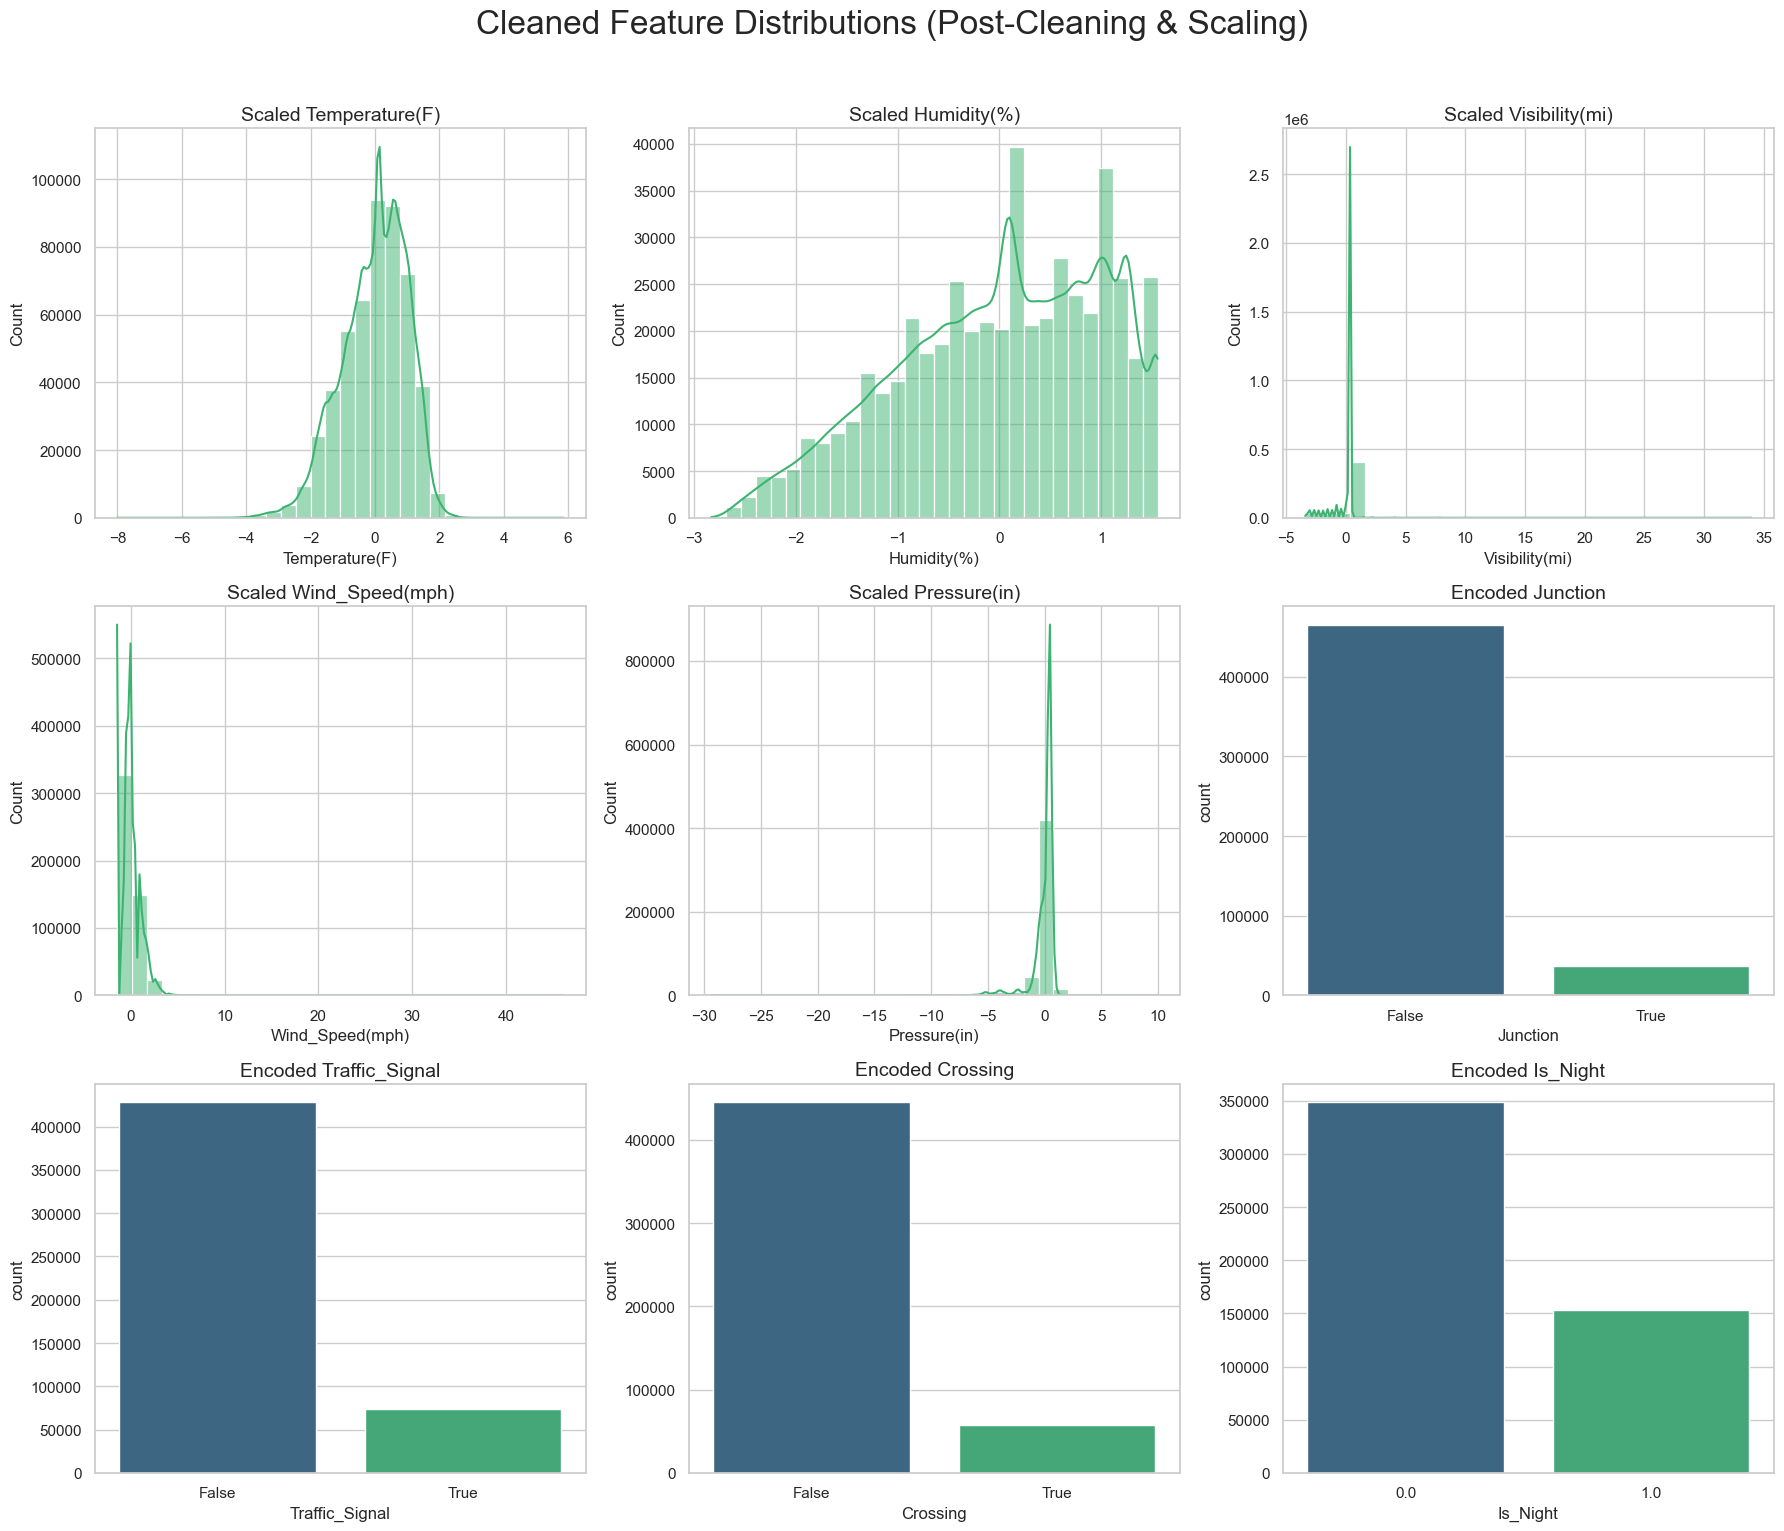

In [7]:
# Select 9 key features to visualize in one big canvas after cleaning
features_to_plot_clean = ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)', 
                          'Pressure(in)', 'Junction', 'Traffic_Signal', 'Crossing', 'Is_Night']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Cleaned Feature Distributions (Post-Cleaning & Scaling)', fontsize=24, y=1.02)
axes = axes.flatten()

for i, feature in enumerate(features_to_plot_clean):
    ax = axes[i]
    data = X[feature]
    
    if feature in numeric_cols:
        sns.histplot(data, bins=30, ax=ax, color='mediumseagreen', kde=True)
        ax.set_title(f'Scaled {feature}', fontsize=14)
        # The x-axis is now standard deviations, not absolute values
    else:
        # Categorical/Boolean features are now 0/1
        sns.countplot(x=data, ax=ax, palette='viridis')
        ax.set_title(f'Encoded {feature}', fontsize=14)

plt.tight_layout()
plt.show()

### Graph 3: Correlation Heatmap

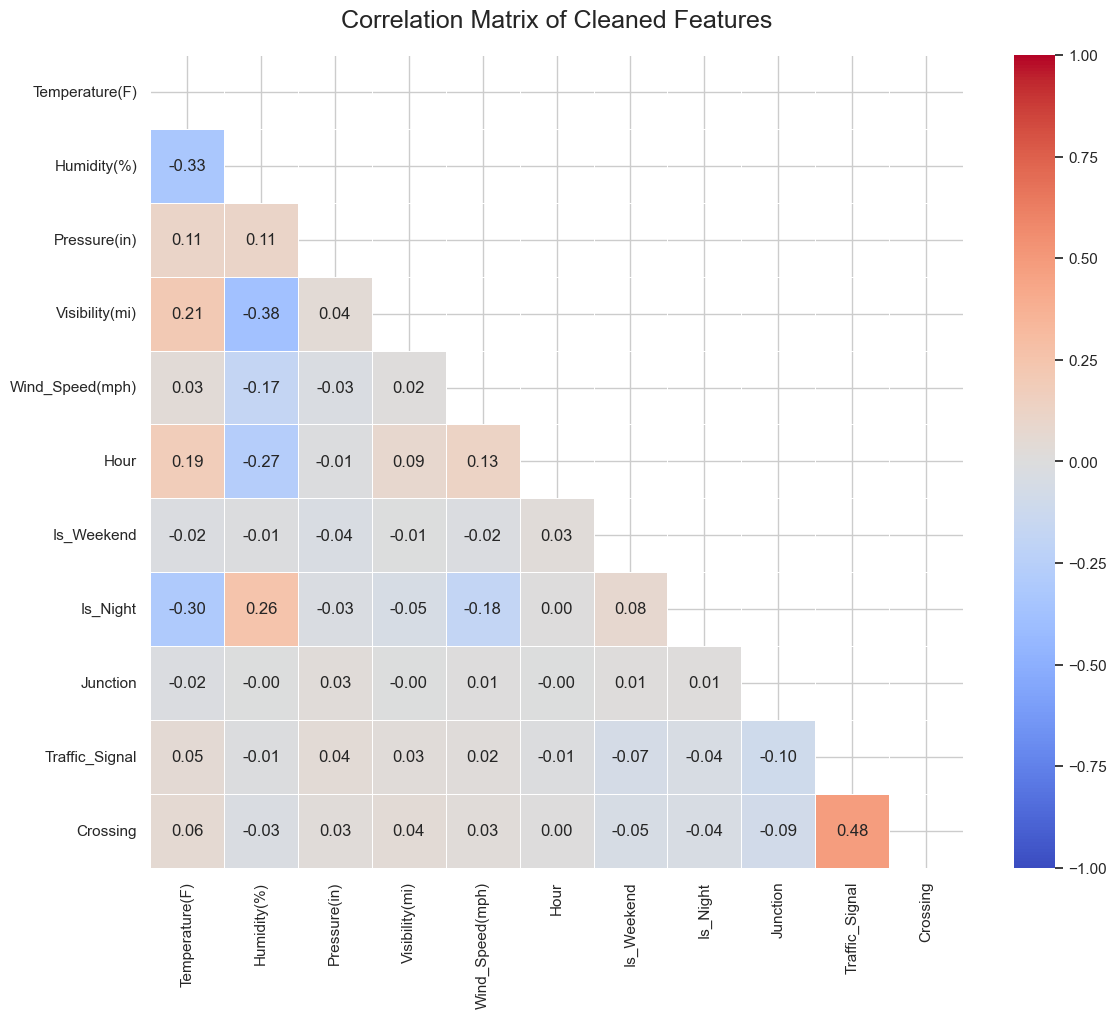

In [8]:
plt.figure(figsize=(12, 10))

# We'll just look at the numeric and core boolean features for the heatmap
core_features = numeric_cols + ['Is_Weekend', 'Is_Night', 'Junction', 'Traffic_Signal', 'Crossing']
corr_matrix = X[core_features].corr()

# Mask the upper triangle so it's easier to read
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5)

plt.title('Correlation Matrix of Cleaned Features', fontsize=18, pad=20)
plt.show()

### Save the Cleaned (But Imbalanced) Data
We save the imbalanced data here. We will apply SMOTE inside Phase 3, 4, and 5 *after* splitting the data to prevent data leakage.

In [15]:
# Ensure outputs directory exists
os.makedirs('../outputs', exist_ok=True)

print("Saving preprocessed (imbalanced) dataset to CSV...")
# Combine X and y back together to save
df_final = pd.concat([X, y], axis=1)

# Save to the outputs folder
df_final.to_csv('../outputs/processed_imbalanced_data.csv', index=False)
print("Saved to outputs/processed_imbalanced_data.csv!")

Saving preprocessed (imbalanced) dataset to CSV...
Saved to outputs/processed_imbalanced_data.csv!
